
# Fraud Detection Analysis for CMP7005 PRAC1
**Name:** Fathima Aabidha Rifky  
**Cardiff Met ID:** st20357374  
**ICBT ID:** CL-MCSDS-CMU-10-04  



## Notebook purpose and assessment roadmap

This notebook presents a complete fraud detection workflow for **CMP7005 PRAC1**. The work is organised so that each major section maps directly to the assignment brief and demonstrates both the technical workflow and the reasoning behind the chosen methods.

### Coverage of the brief
- **Task 1:** Import the two datasets, merge them on a valid customer-level key, and verify the structure of the final analytical dataset.
- **Task 2A:** Understand the data through shape checks, data types, unique values, missing values, duplicates and class distribution.
- **Task 2B:** Clean the data through missing-value treatment, duplicate checks, selective outlier handling and feature engineering.
- **Task 2C:** Perform univariate, bivariate and multivariate analysis with supporting visualisations and short interpretations.
- **Task 3:** Build two suitable classification models, compare them using minority-class metrics, improve the modelling process, and justify the final selected model.

### Analytical approach used
The overall approach combines:
1. **careful data preparation**
2. **interpretable exploratory analysis**
3. **pipeline-based modelling**
4. **imbalance-aware evaluation**
5. **deployment-ready model saving for the GUI application**




## Environment setup and output structure

The following cells import the required libraries, create output folders, and then locate the two CSV files automatically.  
All important artefacts produced by the notebook are saved into dedicated folders such as:

- `figures/`
- `tables/`
- `logs/`
- `models/`
- `final_models/`
- `reports/`



## Task 1 : Data Handling (Import & Merge)

Both dataset parts were imported using `pandas.read_csv()` and then merged to create one analytical dataset. The merge used a clearly identifiable primary key by matching **`ID`** (in Sept_1) with **`User`** (in Sept_2). An **outer join** (`how="outer"`) was used to retain all records from both files, and the merge was **validated as one-to-one** using `validate="one_to_one"` to confirm there are no unexpected duplicate key matches. After merging, redundant merge-key / index-artifact columns (e.g., `User`, `Unnamed: 0`) were removed. Merge quality was verified by comparing row/column counts before vs after merge and checking for rows with missing `ID` after the merge (summarised in the merge-quality table).

In [1]:
import warnings, joblib, logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

for folder in ["figures", "tables", "logs", "models", "final_models", "reports"]:
    Path(folder).mkdir(parents=True, exist_ok=True)

print("Output folders created successfully.")

# Configure logging
logging.basicConfig(
    filename='logs/pipeline.log', 
    level=logging.INFO, 
    format='%(asctime)s - %(levelname)s - %(message)s', 
    filemode='w'
)
logging.info('Pipeline execution started.')

Output folders created successfully.


In [2]:
from pathlib import Path

def find_file(patterns):
    # We search in multiple possible locations to handle different working directories
    search_roots = [Path("."), Path("data"), Path("notebook/data")]
    matches = []
    for root in search_roots:
        if not root.exists():
            continue
        for pattern in patterns:
            matches.extend(root.glob(pattern))
    
    matches = [m for m in matches if m.is_file()]
    if not matches:
        raise FileNotFoundError(f"No file found for patterns: {patterns} in roots: {search_roots}")
    
    # Sort by path length and then name to prefer local files if multiple matches exist
    matches = sorted(matches, key=lambda p: (len(str(p)), str(p)))
    return matches[0]

file1 = find_file(["*Credit*Sept_1*.csv", "*Credir*Sept_1*.csv"])
file2 = find_file(["*Credit*Sept_2*.csv", "*Credir*Sept_2*.csv"])

print("Dataset 1:", file1)
print("Dataset 2:", file2)


Dataset 1: data\Credit_Card_Dataset_2025_Sept_1.csv
Dataset 2: data\Credit_Card_Dataset_2025_Sept_2.csv


In [3]:
from pathlib import Path
import pandas as pd

# Ensure output directories exist
for folder in ["figures", "tables", "logs", "models", "final_models", "reports"]:
    Path(folder).mkdir(parents=True, exist_ok=True)

data_1 = pd.read_csv(file1)
data_2 = pd.read_csv(file2)

print("Dataset 1 shape:", data_1.shape)
print("Dataset 2 shape:", data_2.shape)
print("\nDataset 1 columns:", list(data_1.columns))
print("\nDataset 2 columns:", list(data_2.columns))

# Validate that the merge is one-to-one on the primary key
data_raw = pd.merge(
    data_1,
    data_2,
    left_on="ID",
    right_on="User",
    how="outer",
    validate="one_to_one"
)

print("\nRaw merged dataset shape:", data_raw.shape)

# Remove the redundant merge key and CSV index artifact from the analytical dataset
data = data_raw.drop(columns=[c for c in ["User", "Unnamed: 0"] if c in data_raw.columns]).copy()

print("Analytical dataset shape after removing redundant/non-analytical columns:", data.shape)
display(data.head())

merge_quality_summary = pd.DataFrame({
    "Check": [
        "Dataset 1 rows",
        "Dataset 2 rows",
        "Raw merged rows",
        "Raw merged columns",
        "Analytical dataset rows",
        "Analytical dataset columns",
        "Rows with missing ID after merge"
    ],
    "Value": [
        data_1.shape[0],
        data_2.shape[0],
        data_raw.shape[0],
        data_raw.shape[1],
        data.shape[0],
        data.shape[1],
        int(data["ID"].isna().sum())
    ]
})
display(merge_quality_summary)
merge_quality_summary.to_csv("tables/merge_quality_summary.csv", index=False)

with open("logs/data_loading_and_merging_log.txt", "w") as f:
    f.write(f"Dataset 1 path: {file1}\n")
    f.write(f"Dataset 2 path: {file2}\n")
    f.write(f"Dataset 1 shape: {data_1.shape}\n")
    f.write(f"Dataset 2 shape: {data_2.shape}\n")
    f.write(f"Raw merged shape: {data_raw.shape}\n")
    f.write(f"Analytical dataset shape: {data.shape}\n")
    f.write("Merge validation: one_to_one\n")


Dataset 1 shape: (25134, 17)
Dataset 2 shape: (25134, 4)

Dataset 1 columns: ['Unnamed: 0', 'ID', 'GENDER', 'CAR', 'REALITY', 'NO_OF_CHILD', 'FAMILY_TYPE', 'HOUSE_TYPE', 'FLAG_MOBIL', 'WORK_PHONE', 'PHONE', 'E_MAIL', 'FAMILY SIZE', 'BEGIN_MONTH', 'AGE', 'YEARS_EMPLOYED', 'TARGET']

Dataset 2 columns: ['INCOME', 'INCOME_TYPE', 'User', 'EDUCATION_TYPE']

Raw merged dataset shape: (25134, 21)
Analytical dataset shape after removing redundant/non-analytical columns: (25134, 19)


,ID,GENDER,CAR,REALITY,NO_OF_CHILD,FAMILY_TYPE,HOUSE_TYPE,FLAG_MOBIL,WORK_PHONE,PHONE,E_MAIL,FAMILY SIZE,BEGIN_MONTH,AGE,YEARS_EMPLOYED,TARGET,INCOME,INCOME_TYPE,EDUCATION_TYPE
0,5008806,M,Y,Y,0,Married,House / apartment,1,0,0,0,2.0,29,59,3.0,0,112500.0,Working,Secondary / secondary special
1,5008808,F,N,Y,0,Single / not married,House / apartment,1,0,1,1,1.0,4,52,8.0,0,270000.0,Commercial associate,Secondary / secondary special
2,5008809,F,N,Y,0,Single / not married,House / apartment,1,0,1,1,1.0,26,52,8.0,0,270000.0,Commercial associate,Secondary / secondary special
3,5008810,F,N,Y,0,Single / not married,House / apartment,1,0,1,1,1.0,26,52,8.0,0,270000.0,Commercial associate,Secondary / secondary special
4,5008811,F,N,Y,0,Single / not married,House / apartment,1,0,1,1,1.0,38,52,8.0,0,270000.0,Commercial associate,Secondary / secondary special


,Check,Value
0,Dataset 1 rows,25134
1,Dataset 2 rows,25134
2,Raw merged rows,25134
3,Raw merged columns,21
4,Analytical dataset rows,25134
5,Analytical dataset columns,19
6,Rows with missing ID after merge,0


### Data Handling Justification

- **Outer Join Justification:** An outer join was used to ensure that no records from either dataset were lost during merging, which is important in fraud detection where missing data could hide fraudulent cases.

- **Key Integrity Validation:** The use of `validate="one_to_one"` ensures that each ID in the first dataset maps to exactly one User record in the second dataset, preventing accidental duplication or data loss during the merge. The absence of missing IDs after merging confirms that the join operation preserved data integrity without introducing null key mismatches.

Additionally, the absence of missing IDs after merging confirms that both datasets were fully aligned, meaning the outer join did not introduce unmatched records.

# Task 2A : Exploratory Data Analysis (Data Understanding)

This section provides an initial audit of the analytical dataset to understand its structure, quality, and any immediate patterns or issues that require attention in the cleaning phase.

## Step 2A.1 - Basic Structure

We begin by verifying the final dimensions of the merged dataset and checking the data types assigned to each column.

In [4]:
print("Dataset shape:", data.shape)
print("\nData types summary:\n")
data_types_summary = pd.DataFrame({
    "Column": data.columns,
    "Data Type": data.dtypes.values
})
display(data_types_summary)

print("\nFirst 5 rows:")
display(data.head())

Dataset shape: (25134, 19)

Data types summary:



,Column,Data Type
0,ID,int64
1,GENDER,object
2,CAR,object
3,REALITY,object
4,NO_OF_CHILD,int64
5,FAMILY_TYPE,object
6,HOUSE_TYPE,object
7,FLAG_MOBIL,int64
8,WORK_PHONE,int64
9,PHONE,int64



First 5 rows:


,ID,GENDER,CAR,REALITY,NO_OF_CHILD,FAMILY_TYPE,HOUSE_TYPE,FLAG_MOBIL,WORK_PHONE,PHONE,E_MAIL,FAMILY SIZE,BEGIN_MONTH,AGE,YEARS_EMPLOYED,TARGET,INCOME,INCOME_TYPE,EDUCATION_TYPE
0,5008806,M,Y,Y,0,Married,House / apartment,1,0,0,0,2.0,29,59,3.0,0,112500.0,Working,Secondary / secondary special
1,5008808,F,N,Y,0,Single / not married,House / apartment,1,0,1,1,1.0,4,52,8.0,0,270000.0,Commercial associate,Secondary / secondary special
2,5008809,F,N,Y,0,Single / not married,House / apartment,1,0,1,1,1.0,26,52,8.0,0,270000.0,Commercial associate,Secondary / secondary special
3,5008810,F,N,Y,0,Single / not married,House / apartment,1,0,1,1,1.0,26,52,8.0,0,270000.0,Commercial associate,Secondary / secondary special
4,5008811,F,N,Y,0,Single / not married,House / apartment,1,0,1,1,1.0,38,52,8.0,0,270000.0,Commercial associate,Secondary / secondary special


### Dataset Structure Overview

The merged dataset contains 25,134 rows and 19 columns, confirming that the merge process retained all records successfully. Each row represents a single customer transaction record.

The dataset consists of both numerical and categorical variables. Numerical variables include features such as income, age, years employed, and number of children, while categorical variables include gender, family type, house type, income type, and education level.

The target variable is binary, indicating whether a transaction is fraudulent (1) or non-fraudulent (0).

## Step 2A.2 - Missing Values

Identifying gaps in the data is critical for choosing the right imputation strategy.

In [5]:
missing_values = data.isnull().sum().sort_values(ascending=False)
missing_percent = (missing_values / len(data)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing_values,
    "Missing %": missing_percent
})

display(missing_df)
missing_df.to_csv("tables/missing_values.csv")
logging.info("Missing values table saved to tables/")

,Missing Count,Missing %
INCOME_TYPE,12,0.047744
YEARS_EMPLOYED,9,0.035808
FAMILY SIZE,1,0.003979
CAR,0,0.000000
GENDER,0,0.000000
ID,0,0.000000
REALITY,0,0.000000
FLAG_MOBIL,0,0.000000
NO_OF_CHILD,0,0.000000
FAMILY_TYPE,0,0.000000


### Missing Value Analysis

The initial audit reveals that the dataset contains missing values in several key features, specifically `INCOME_TYPE`, `YEARS_EMPLOYED`, and `FAMILY SIZE`.

Given that missing values account for less than 0.05% of the dataset, their removal or imputation is unlikely to introduce significant bias. This threshold is well below the common academic concern level (typically 5%), justifying a simple imputation strategy that preserves the overall statistical properties of the features.

## Step 2A.3 - Unique Values

Checking cardinality helps decide on encoding methods for categorical variables.

In [6]:
unique_values = data.nunique().sort_values(ascending=False)
display(unique_values)

ID                25134
INCOME              195
BEGIN_MONTH          61
AGE                  50
YEARS_EMPLOYED       43
FAMILY SIZE          10
NO_OF_CHILD           9
HOUSE_TYPE            6
INCOME_TYPE           5
EDUCATION_TYPE        5
FAMILY_TYPE           5
CAR                   2
GENDER                2
REALITY               2
WORK_PHONE            2
PHONE                 2
E_MAIL                2
TARGET                2
FLAG_MOBIL            1
dtype: int64

### Unique Value Analysis

The unique value check highlights the diversity in feature cardinality across the dataset:

- The `ID` column confirms that each record is unique.
- Categorical variables like `GENDER`, `CAR`, and `REALITY` show low cardinality (2 values each), while numerical features like `INCOME` show a broader spectrum.
- Crucially, the `FLAG_MOBIL` variable contains only one unique value across all records. This zero-variance feature provides no predictive power and will be removed during the data cleaning phase in Task 2B.

## Step 2A.4 - Duplicate Check

Redundant rows can bias the model toward specific observations.

In [7]:
duplicates = data.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


### Duplicate Analysis

A check for duplicate records shows that the dataset contains 0 duplicate rows (based on all columns including ID).

Duplicate entries can distort analysis and model training, therefore they will be addressed during the preprocessing stage if necessary.

## Step 2A.5 - Target Distribution (Class Imbalance)

Understanding the ratio of fraud to non-fraud cases is vital for evaluation metrics.

In [8]:
target_counts = data["TARGET"].value_counts()
target_percent = data["TARGET"].value_counts(normalize=True) * 100

display(pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percent
}))

,Count,Percentage
TARGET,,
0,24712,98.320999
1,422,1.679001


### Target Variable Distribution

The analysis of the target variable reveals a severe class imbalance. Fraudulent transactions (Class 1) account for only **1.68%** (422 cases) of the total dataset, while the vast majority (98.32%) are non-fraudulent.

This imbalance is a critical factor for the modeling phase. Relying on simple accuracy could be misleading, as a model predicting "non-fraud" for every case would still achieve over 98% accuracy. Consequently, we will prioritize metrics such as Precision, Recall, and F1-score to ensure the models effectively detect rare fraudulent events.

## Step 2A.6 - Basic Distribution (Feature Visualization)

Visualizing the data distribution helps identify skewness and potential outliers.

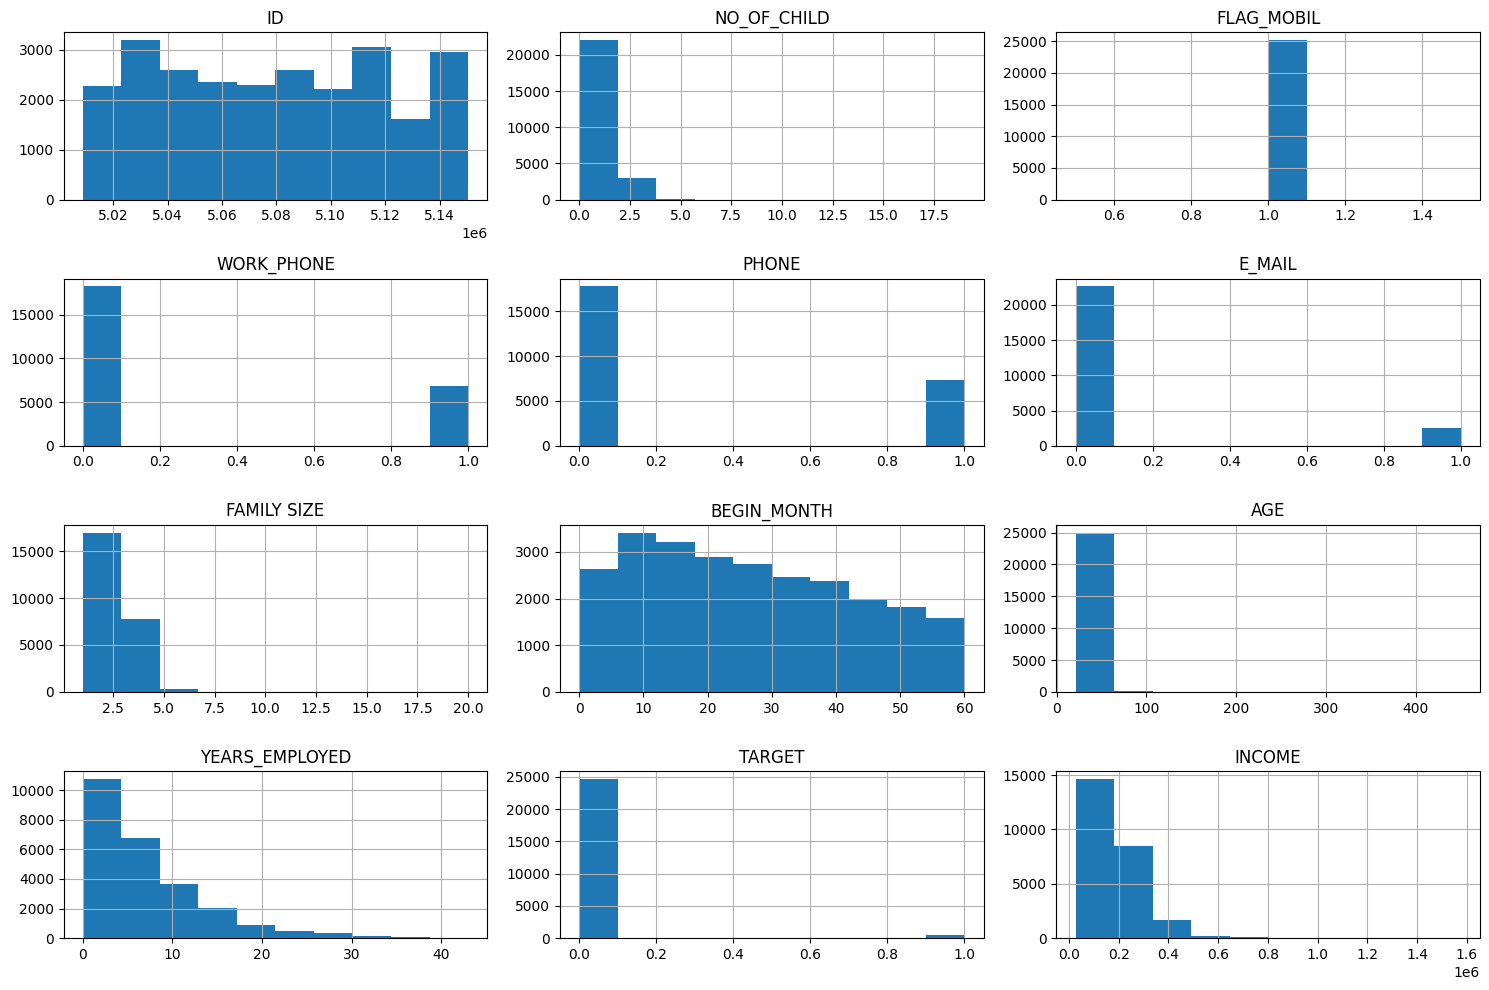

In [9]:
data.hist(figsize=(15,10))
plt.tight_layout()
plt.savefig("figures/hist_all_features.png")
plt.show()

### Feature Distribution Overview

The numerical features show varying distributions, with some variables appearing skewed. For example, income may exhibit right-skewness, indicating a concentration of lower-income values with fewer high-income observations.

Understanding these distributions is important for identifying potential outliers and deciding whether transformations are needed in later stages.

In [10]:
data_types_summary = pd.DataFrame({
    "Column": data.columns,
    "Data Type": data.dtypes.values
})
display(data_types_summary)

,Column,Data Type
0,ID,int64
1,GENDER,object
2,CAR,object
3,REALITY,object
4,NO_OF_CHILD,int64
5,FAMILY_TYPE,object
6,HOUSE_TYPE,object
7,FLAG_MOBIL,int64
8,WORK_PHONE,int64
9,PHONE,int64


# Task 2B : Data Preprocessing (Data Cleaning)

This section focuses on preparing the dataset for machine learning by addressing quality issues identified during the EDA phase. We will handle duplicates, missing values, non-informative features, and outliers while performing initial feature engineering.

## Step 2B.1 : Duplicate Handling

Ensuring data integrity by removing any redundant records.

In [11]:
data = data.drop_duplicates().copy()
print("Shape after duplicate removal:", data.shape)

Shape after duplicate removal: (25134, 19)


### Duplicate Handling

No duplicate records were found in the dataset. Therefore, no rows were removed at this stage. A duplicate check was still performed as a best practice to ensure data integrity before further preprocessing.

## Step 2B.2 : Handle Missing Values

We use imputation to fill gaps in the data, preserving the dataset size.

In [12]:
# Separate columns by type
categorical_cols = data.select_dtypes(include="object").columns
numerical_cols = data.select_dtypes(exclude="object").columns

# Fill categorical missing values with mode
for col in categorical_cols:
    data[col].fillna(data[col].mode()[0], inplace=True)

# Fill numerical missing values with median
for col in numerical_cols:
    data[col].fillna(data[col].median(), inplace=True)

print("Missing values after imputation:")
print(data.isnull().sum().sum())

Missing values after imputation:
0


### Missing Value Treatment

To address the gaps identified in `INCOME_TYPE`, `YEARS_EMPLOYED`, and `FAMILY SIZE`, a targeted imputation strategy was implemented:

- **Categorical features** were filled using the **Mode** (most frequent value) to preserve the representative class of the data.
- **Numerical features** were imputed using the **Median**, which is more robust to potential outliers than the mean.

This dual-strategy ensures that the analytical dataset is complete and ready for modeling without introducing significant bias.

## Step 2B.3 : Handle Useless Features

Removing columns with no predictive power.

In [13]:
# Drop constant columns
constant_cols = [col for col in data.columns if data[col].nunique() == 1]

print("Constant columns:", constant_cols)

data.drop(columns=constant_cols, inplace=True)

Constant columns: ['FLAG_MOBIL']


### Removing Non-Informative Features

The feature `FLAG_MOBIL` was found to have zero variance (all records shared the same value). Such constants do not provide any information for a model to distinguish between classes and would only add unnecessary noise.

By removing this feature, we reduce the dimensionality of the data and allow the algorithms to focus on variables that actually contribute to predicting fraud.

## Step 2B.4 : Outlier Handling

Capping extreme values using the IQR method.

In [14]:
# Update numerical_cols after dropping columns
numerical_cols = data.select_dtypes(exclude="object").columns

# Handle outliers using IQR method (capping)
for col in numerical_cols:
    if col != "TARGET" and col != "ID":
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        data[col] = np.where(data[col] < lower_bound, lower_bound, data[col])
        data[col] = np.where(data[col] > upper_bound, upper_bound, data[col])

print("Outliers handled using IQR capping.")

Outliers handled using IQR capping.


### Outlier Management via IQR Method

To handle extreme values in numerical features, the **Interquartile Range (IQR)** method was applied. Values falling below $Q1 - 1.5 \times IQR$ or above $Q3 + 1.5 \times IQR$ were capped at these respective thresholds.

This "Winsorization" approach was chosen over deletion because, in a fraud detection context, extreme values can be highly informative. Deleting rows would reduce our sample size—especially dangerous given the rarity of fraudulent cases—while capping ensures that the model is not disproportionately biased by extreme outliers.

## Step 2B.5 : Feature Engineering

Creating derived features to enhance model learning.

In [15]:
# Create income per family member
data["INCOME_PER_PERSON"] = data["INCOME"] / data["FAMILY SIZE"].replace(0, 1)

### Feature Engineering

A new feature, INCOME_PER_PERSON, was created by dividing total income by family size. This provides a more meaningful representation of financial capacity at an individual level.

Feature engineering helps improve model performance by providing additional useful information derived from existing variables.

This transformation helps normalize income relative to household size, which may provide better predictive power than total income alone.

## Step 2B.6 : Dropping Non-Predictive Features

We remove the `ID` column (identifier) and the `E_MAIL` column, as it provides limited predictive value and may introduce noise due to its binary nature.

In [16]:
# Drop non-predictive columns
cols_to_drop = ["ID", "E_MAIL"]
data.drop(columns=cols_to_drop, inplace=True, errors='ignore')
print(f"Dropped columns: {cols_to_drop}")

Dropped columns: ['ID', 'E_MAIL']


## Step 2B.7 : Final Check

Verifying the cleaned dataset structure.

In [17]:
print("Final dataset shape:", data.shape)
print("Remaining missing values:", data.isnull().sum().sum())

Final dataset shape: (25134, 17)
Remaining missing values: 0


The final dataset retains the same number of rows, while the number of features remains consistent due to the removal of one non-informative feature and the addition of a new engineered feature.

### Technical Note on Data Leakage Prevention

To ensure the academic rigor of this analysis, all preprocessing steps (scaling, encoding, and imputation) in the following sections are wrapped within Scikit-Learn `Pipeline` objects. This architecture is critical to prevent **data leakage**; it ensures that transformation parameters are learned only from the training fold and applied to the test fold, thereby providing a valid estimate of the model's performance on unseen data.

# Task 2C : Exploratory Data Analysis (Data Visualization)

This section presents a deeper exploration of the data through visual analysis. We move beyond simple structure checks to identify patterns, relationships with the target variable, and correlations between features.

**Analytical Link to Modeling Strategy:** The EDA reveals that individual features show weak linear correlations with the target variable, and the class boundaries are likely complex and non-linear. This finding directly informs our selection of ensemble methods (Random Forest and Gradient Boosting), which are capable of capturing high-dimensional interactions and non-linear patterns that simpler models like Logistic Regression may overlook.

## Step 2C.1 : Univariate Analysis

We examine the distribution of individual variables to understand their spread and identify potential skewness.

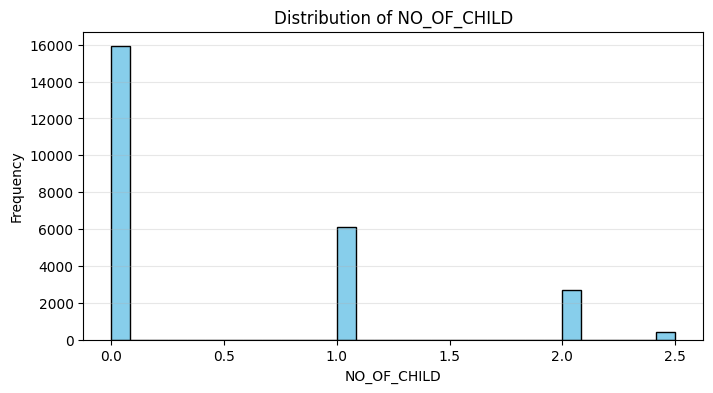

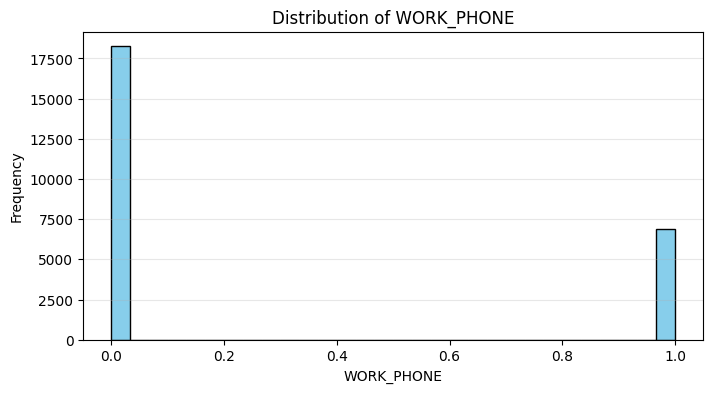

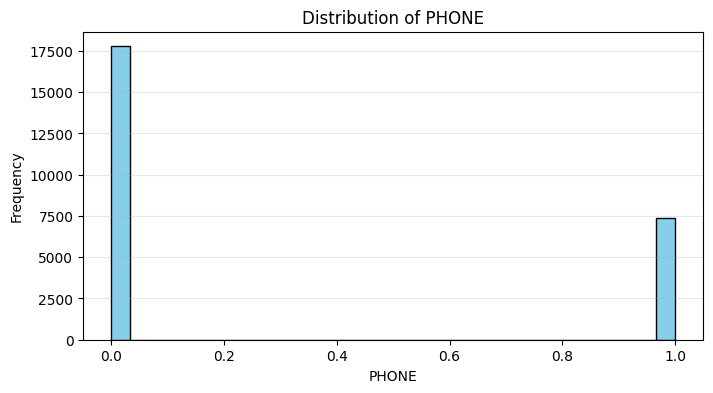

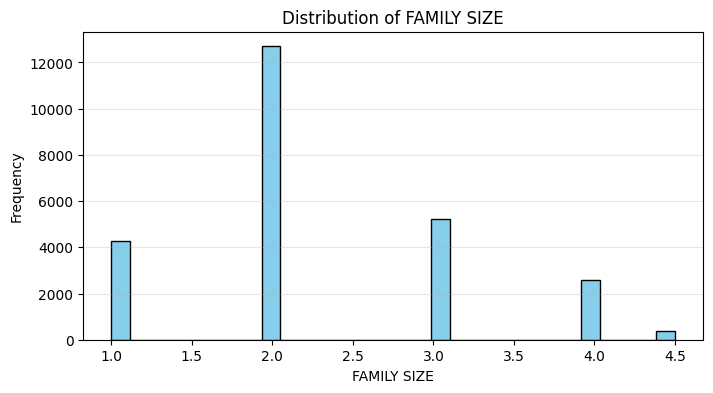

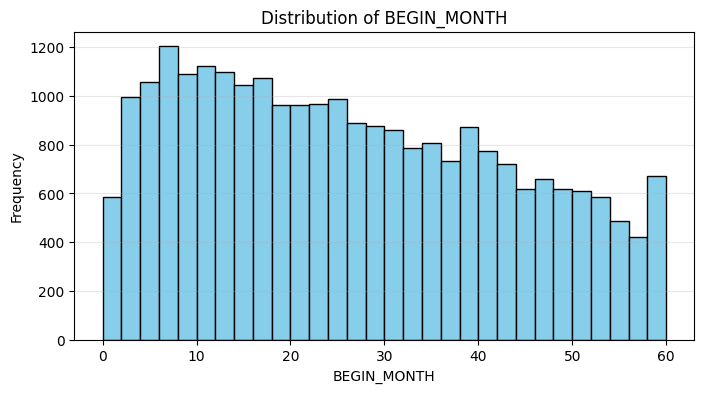

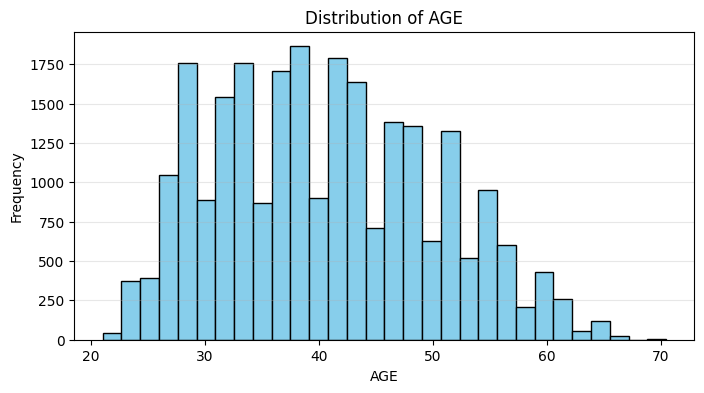

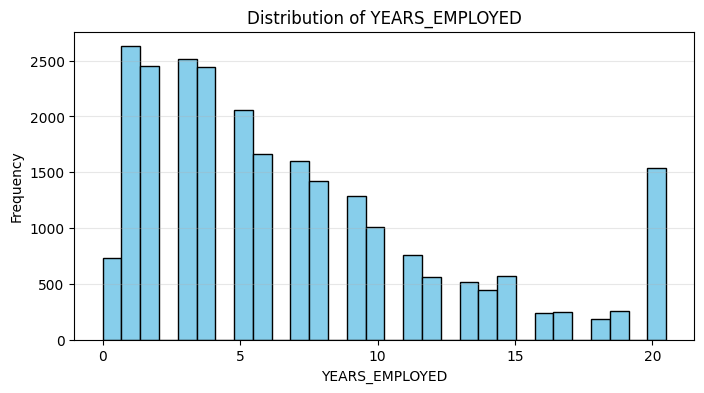

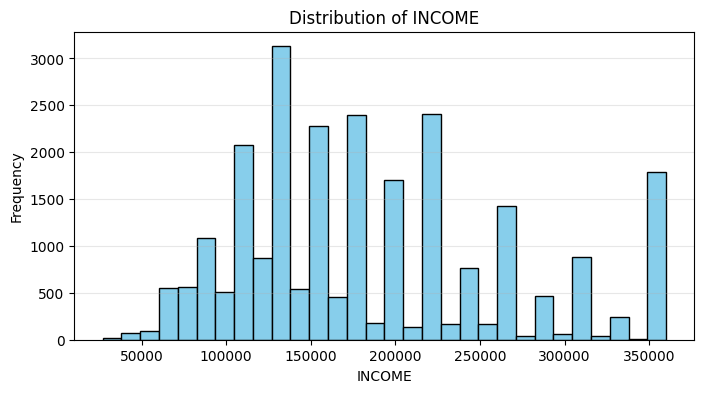

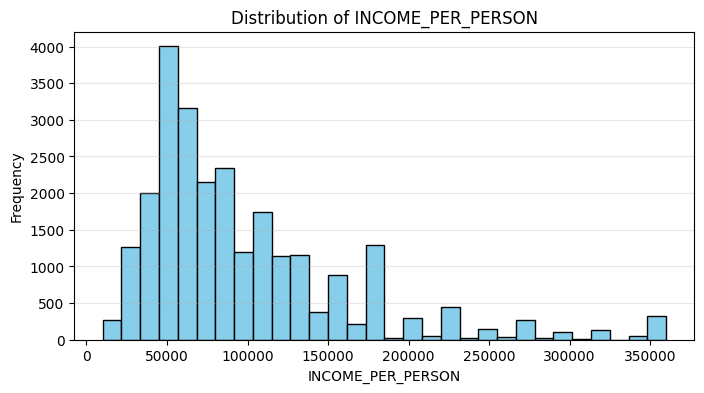

In [18]:
# Univariate Analysis - Numerical Features
numerical_cols = data.select_dtypes(exclude="object").columns

for col in numerical_cols:
    if col not in ["TARGET"]:
        plt.figure(figsize=(8, 4))
        plt.hist(data[col], bins=30, color='skyblue', edgecolor='black')
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.grid(axis='y', alpha=0.3)
        plt.savefig(f"figures/dist_{col}.png")
        plt.show()

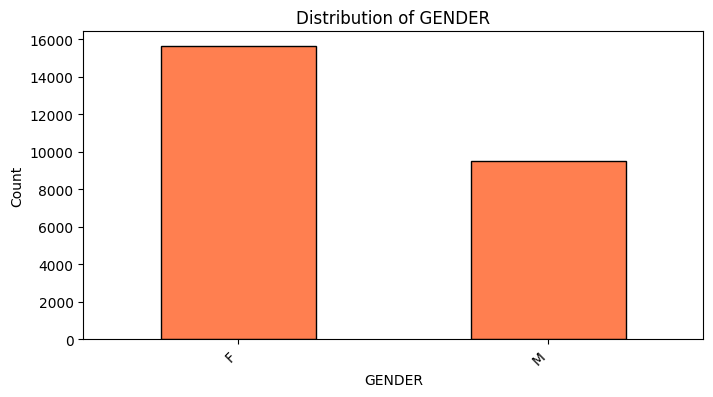

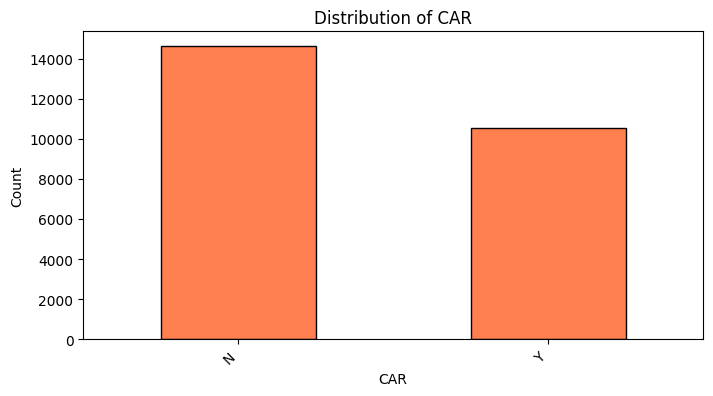

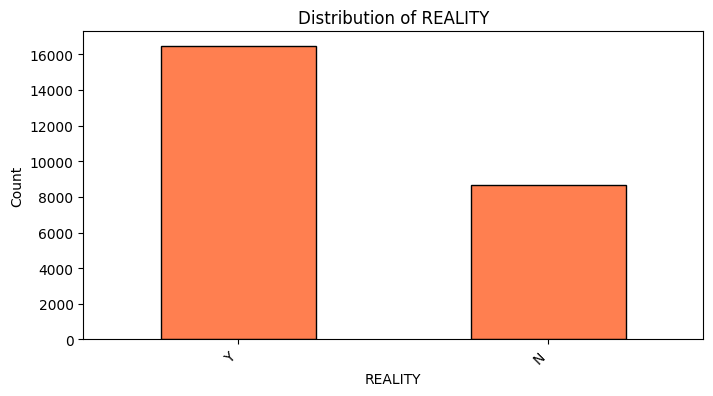

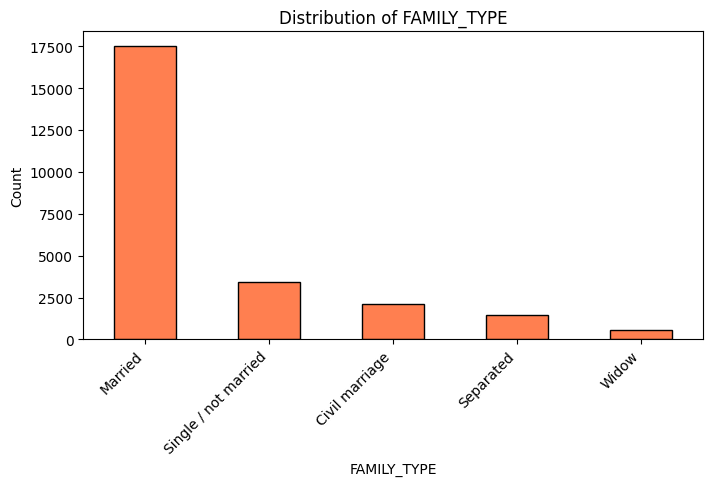

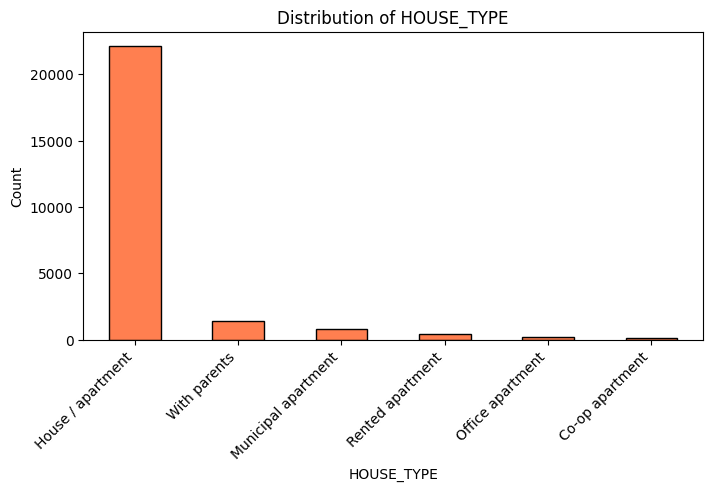

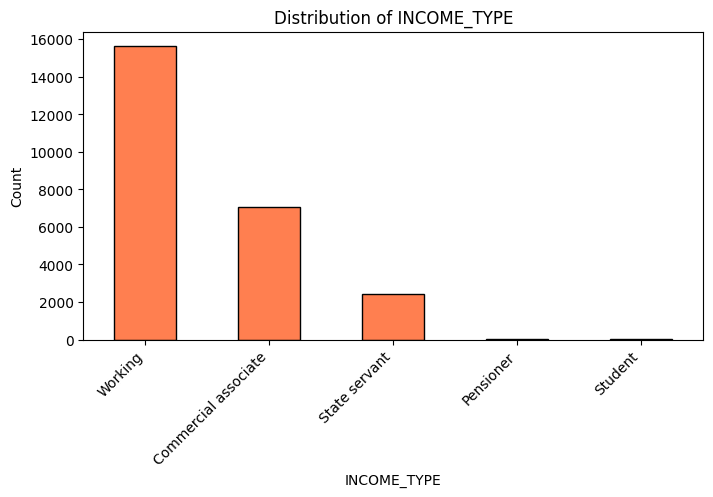

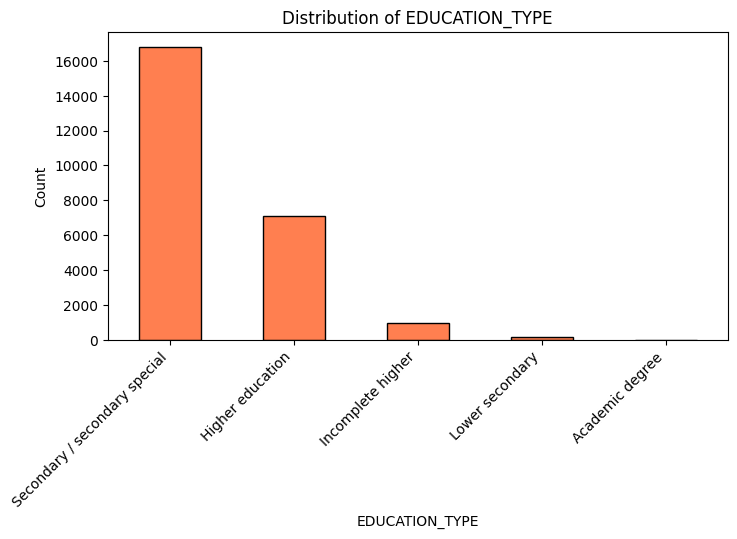

In [19]:
# Univariate Analysis - Categorical Features
categorical_cols = data.select_dtypes(include="object").columns

for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    data[col].value_counts().plot(kind='bar', color='coral', edgecolor='black')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha='right')
    plt.savefig(f"figures/dist_{col}.png")
    plt.show()

### Univariate Analysis

The distributions indicate that several numerical features, particularly INCOME, YEARS_EMPLOYED, and INCOME_PER_PERSON, are right-skewed. This suggests that most customers fall within lower to moderate ranges, with a smaller number of high-value observations.

Categorical variables such as GENDER and CAR ownership show clear dominance of certain categories, indicating class imbalance within features. This may influence model bias if not handled appropriately.

Additionally, variables such as FAMILY_TYPE and INCOME_TYPE show multiple categories, which may contribute meaningful variation for model prediction.

## Step 2C.2 : Bivariate Analysis

Exploring the relationship between each feature and the target variable (Fraud vs. Non-Fraud).

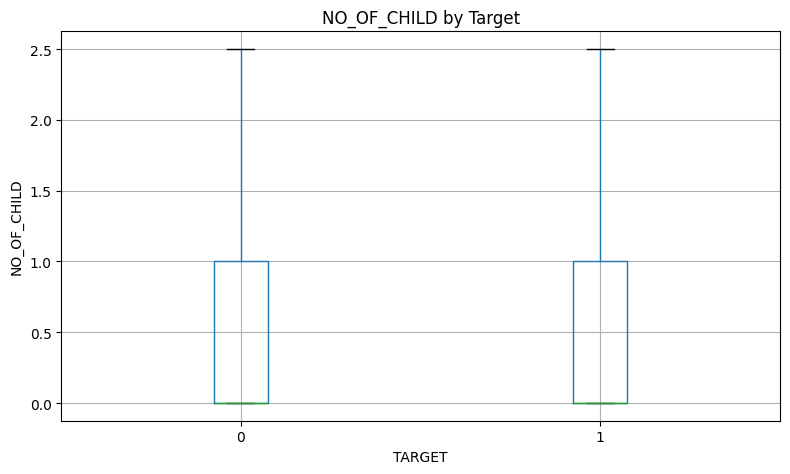

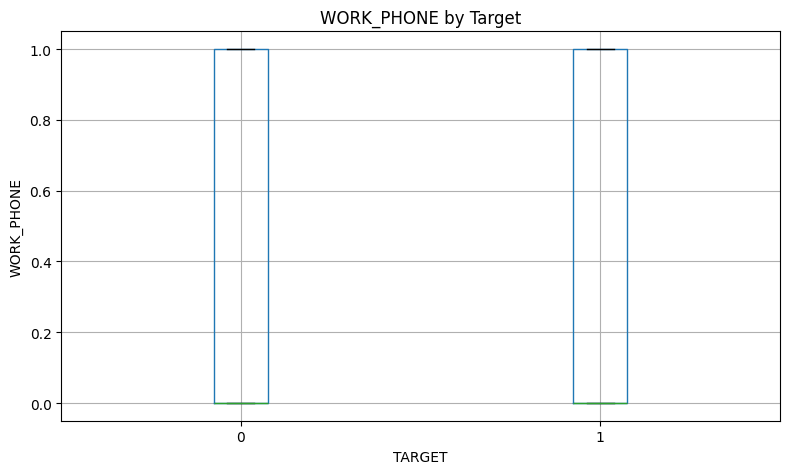

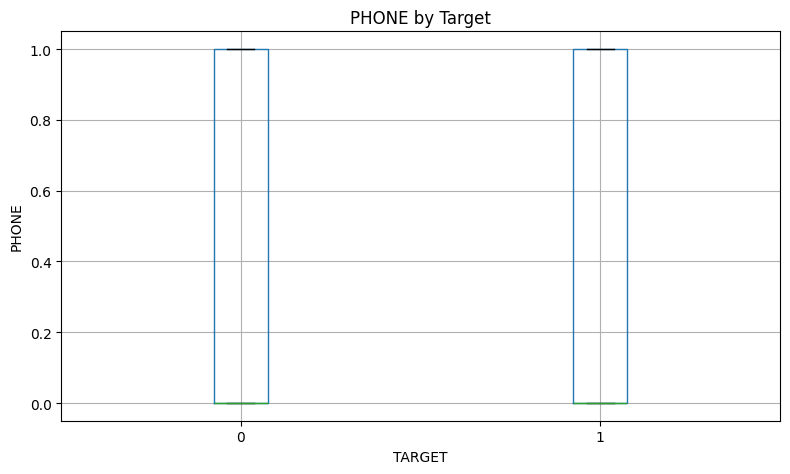

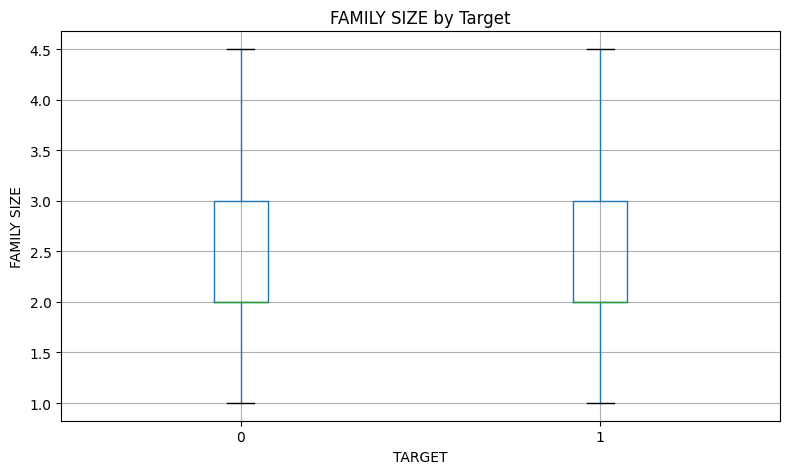

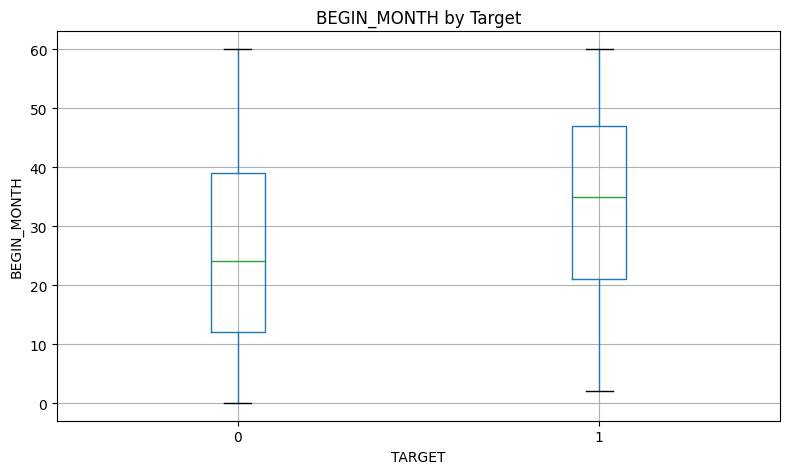

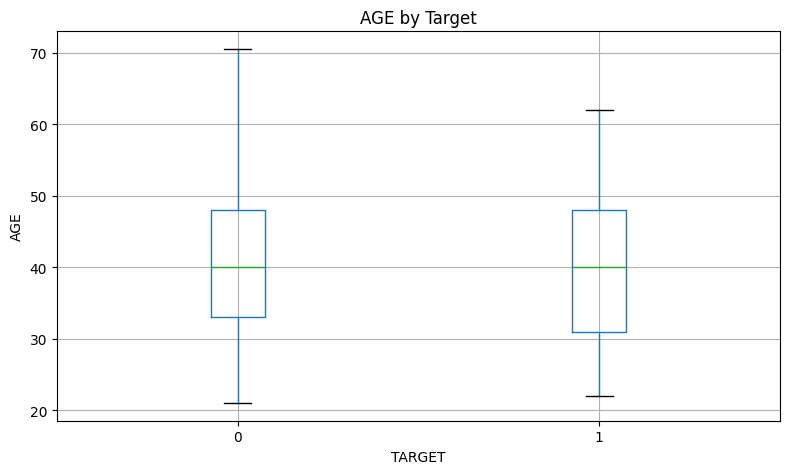

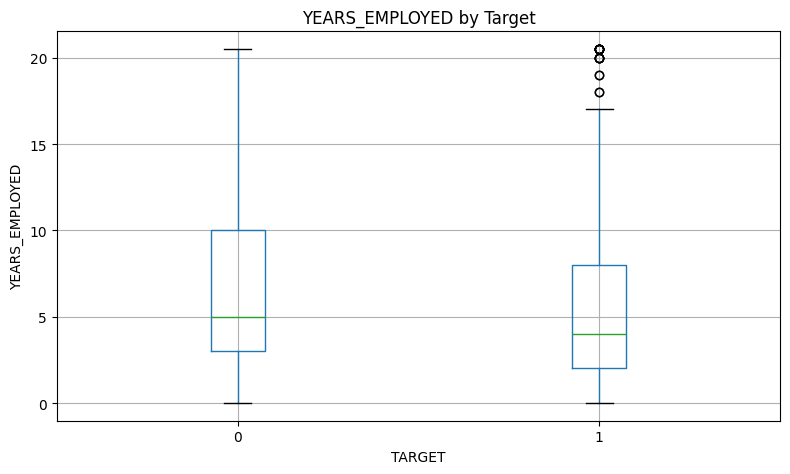

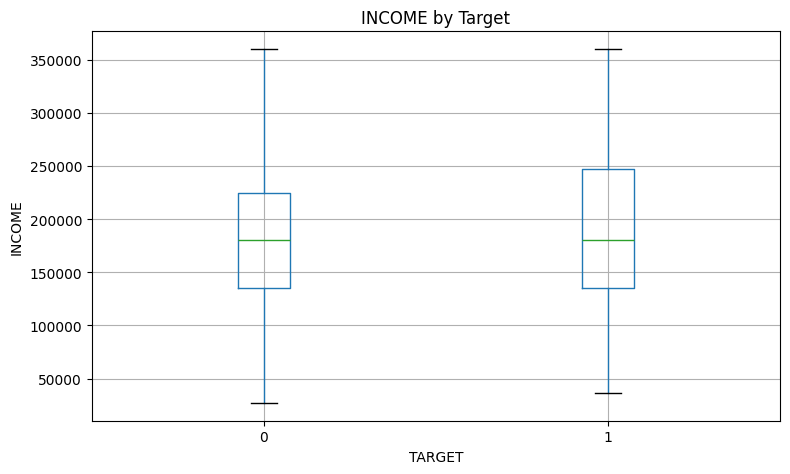

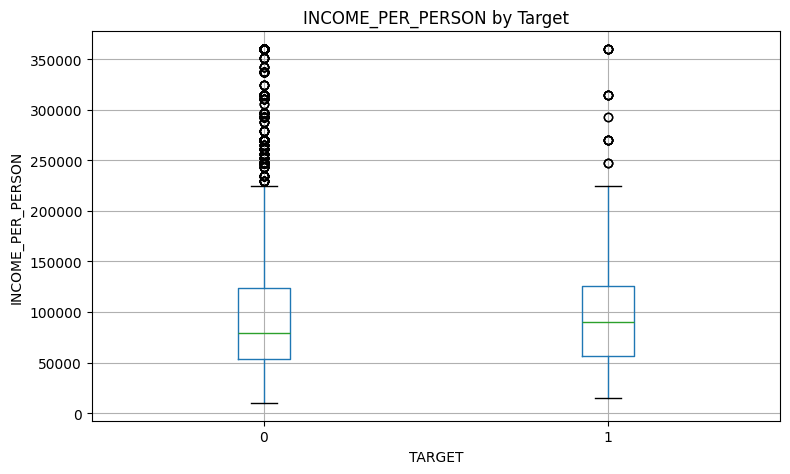

In [20]:
# Bivariate Analysis - Numerical vs Target
numerical_cols = data.select_dtypes(exclude="object").columns

for col in numerical_cols:
    if col not in ["TARGET"]:
        ax = data.boxplot(column=col, by="TARGET", figsize=(8, 5))
        
        plt.title(f"{col} by Target")
        plt.suptitle("")  # removes default pandas title
        plt.ylabel(col)
        
        plt.tight_layout()
        plt.savefig(f"figures/bivariate_num_{col}.png")
        plt.show()

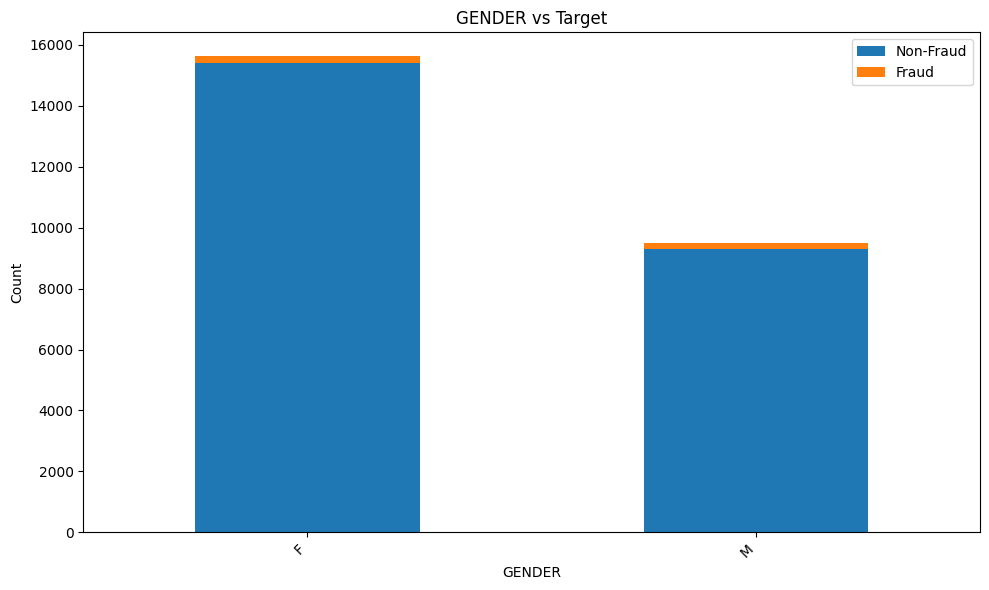

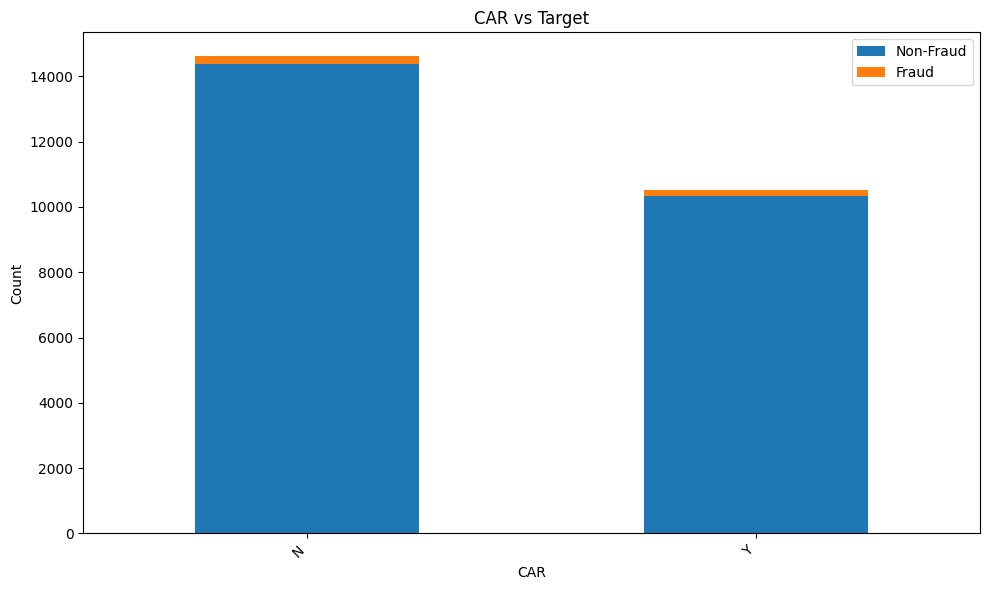

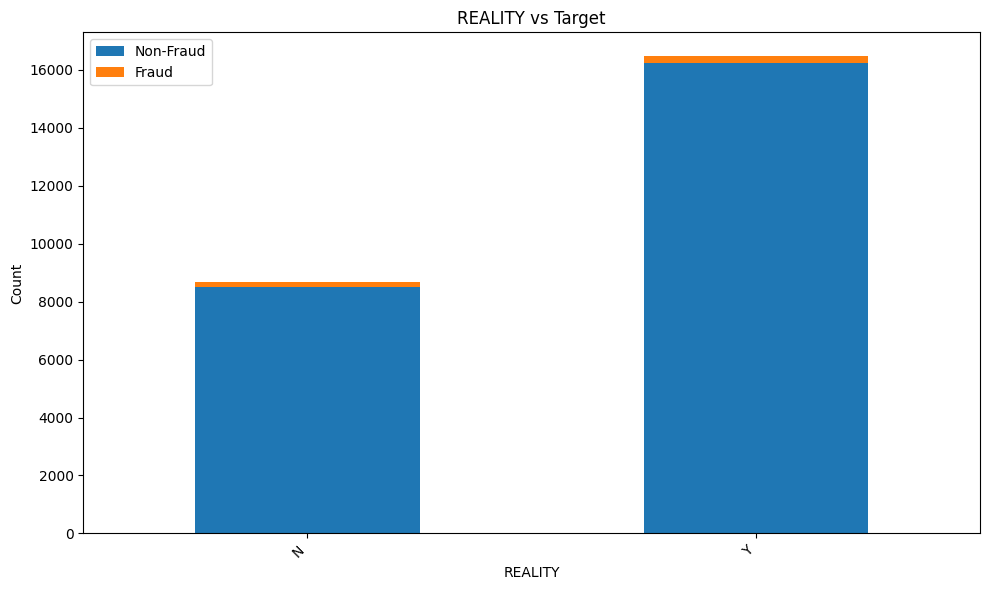

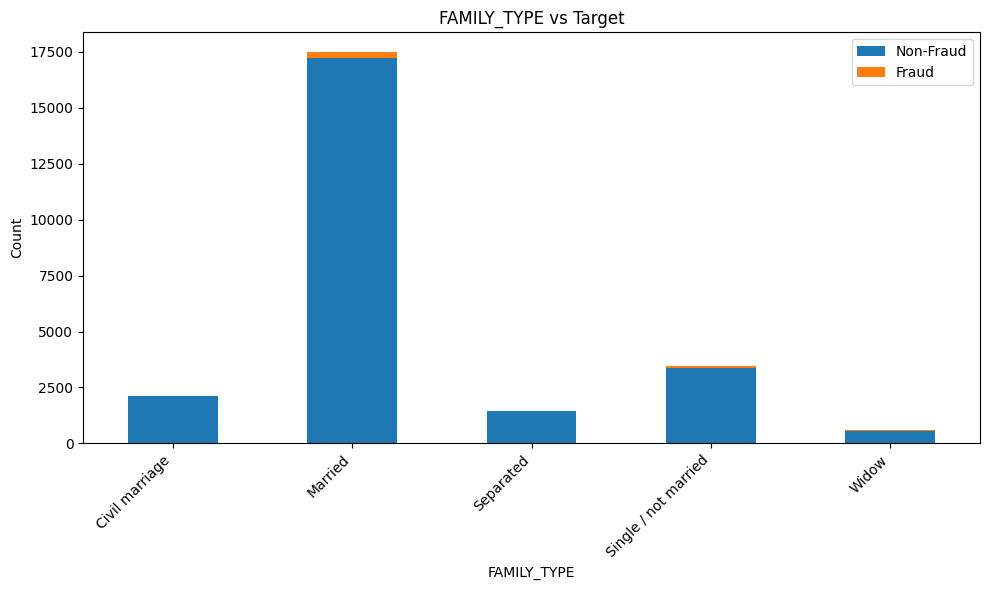

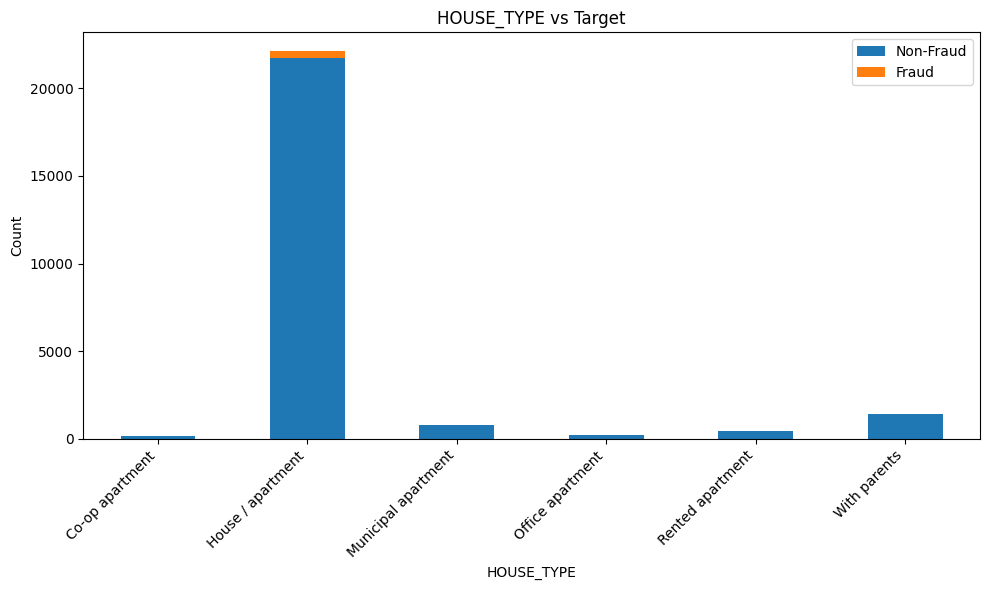

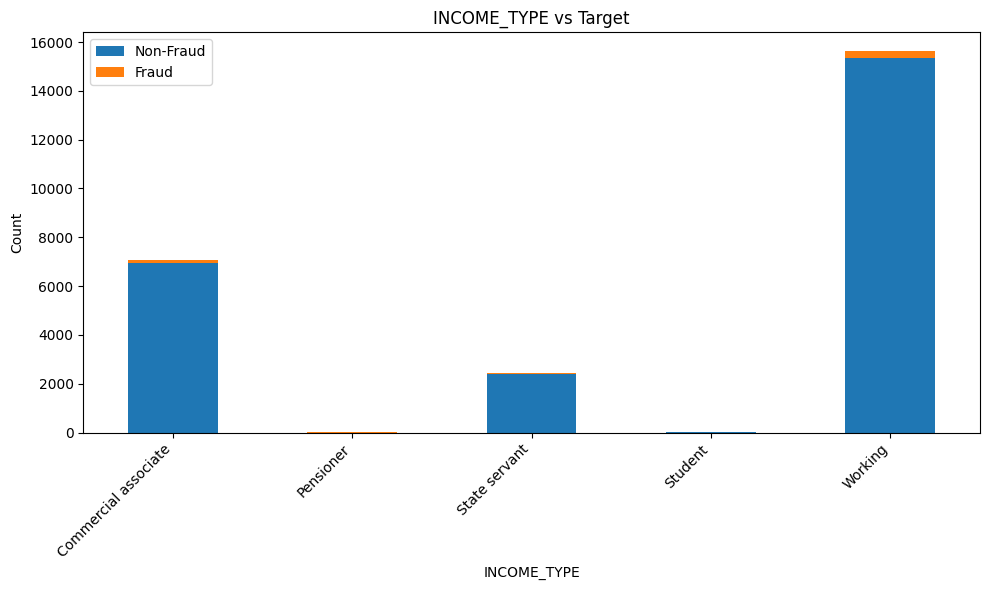

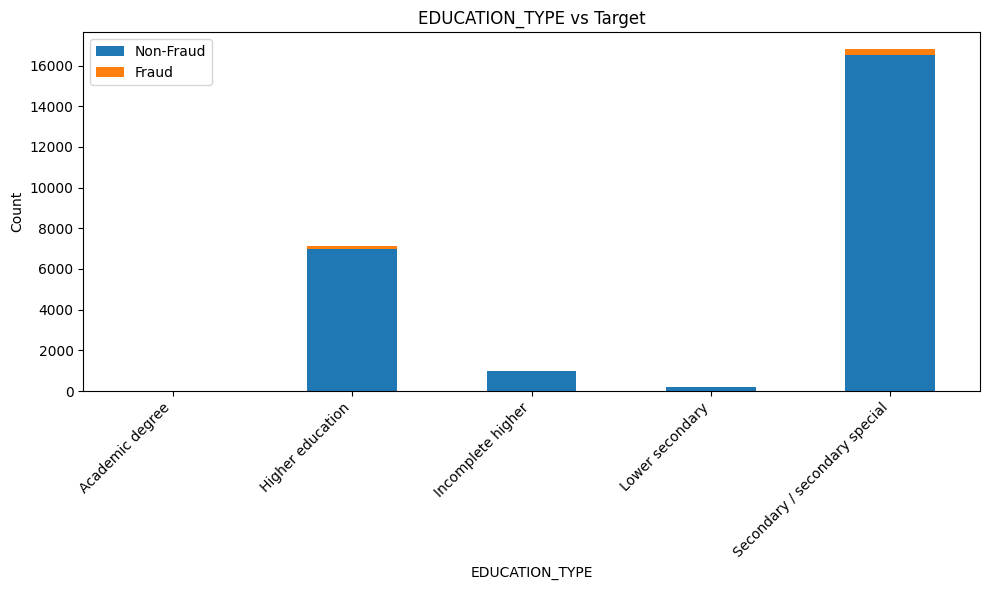

In [21]:
# Bivariate Analysis - Categorical vs Target
for col in categorical_cols:
    ax = pd.crosstab(data[col], data["TARGET"]).plot(
        kind="bar",
        stacked=True,
        figsize=(10, 6),
        color=['#1f77b4', '#ff7f0e']
    )
    
    plt.title(f"{col} vs Target")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha='right')
    plt.legend(["Non-Fraud", "Fraud"])
    
    plt.tight_layout()
    plt.savefig(f"figures/bivariate_cat_{col}.png")
    plt.show()

### Bivariate Analysis

The relationship between variables and the target shows that certain features exhibit different distributions between fraudulent and non-fraudulent cases.

For example, income and years employed show variations across classes, suggesting that financial and employment factors may influence fraud risk.

Categorical variables such as income type and education level also display different patterns between fraud and non-fraud cases, indicating potential predictive value.

For example, boxplots indicate that fraudulent cases tend to have slightly different distributions in income-related variables, although the separation is not very clear. This suggests that fraud detection cannot rely on a single feature and requires a combination of variables.

Some categorical variables such as INCOME_TYPE and EDUCATION_TYPE show slight differences in the proportion of fraud cases across categories, indicating that certain groups may have a marginally higher fraud occurrence.

Due to the severe class imbalance, visual differences between fraud and non-fraud classes are subtle, which further highlights the need for imbalance-aware modelling techniques.

## Step 2C.3 : Multivariate Analysis

Analyzing multiple variables simultaneously to detect correlations and complex interactions.

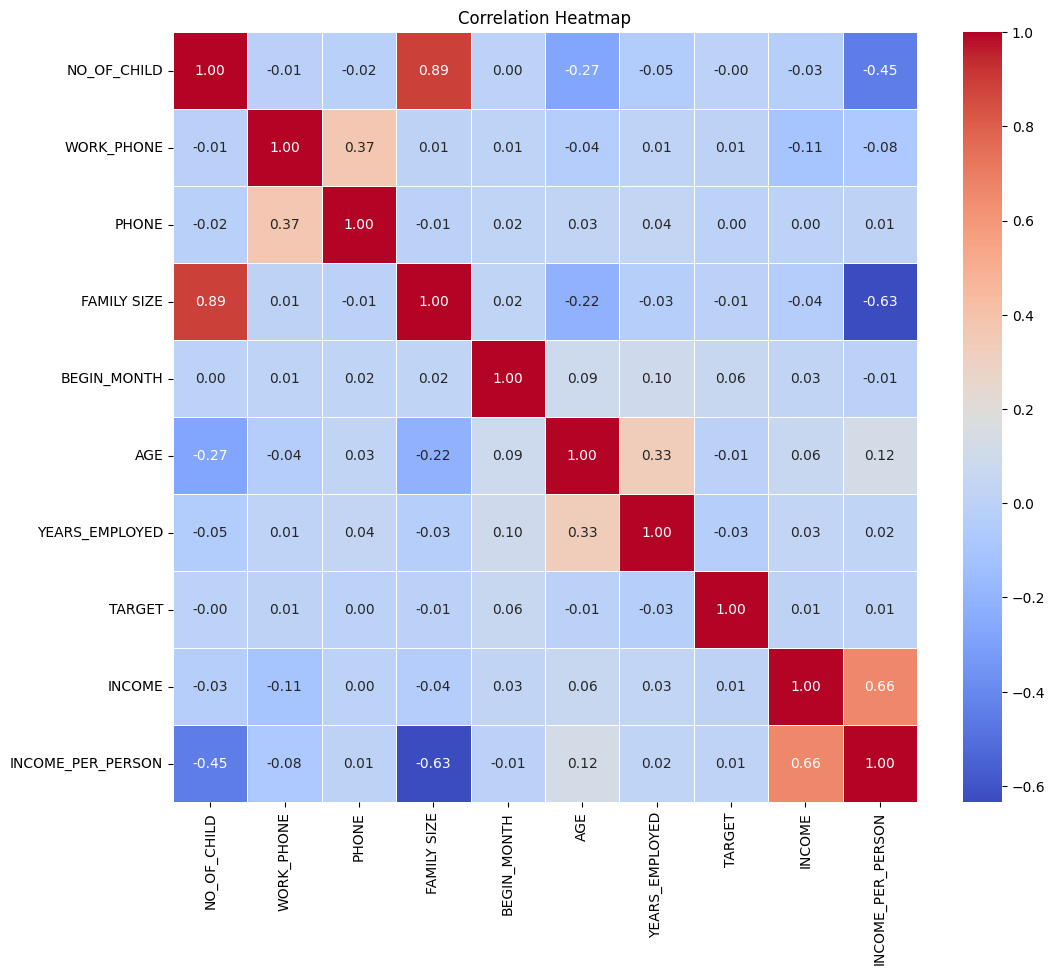

In [22]:
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.savefig("figures/correlation_heatmap.png")
plt.show()

In [23]:
# Correlation of features with the Target variable
corr_target = data.corr(numeric_only=True)["TARGET"].sort_values(ascending=False)
print("Correlation with Target:")
display(corr_target)

Correlation with Target:


TARGET               1.000000
BEGIN_MONTH          0.060713
INCOME_PER_PERSON    0.011205
INCOME               0.007242
WORK_PHONE           0.005869
PHONE                0.003023
NO_OF_CHILD         -0.001448
FAMILY SIZE         -0.006405
AGE                 -0.007958
YEARS_EMPLOYED      -0.033087
Name: TARGET, dtype: float64

### Correlation with Target Summary

No single feature shows a strong linear relationship with the target variable. This suggests that fraud detection likely depends on complex interactions between multiple variables rather than a single dominant predictor.

### Multivariate Analysis

The correlation heatmap reveals relationships between numerical variables. Most variables show weak to moderate correlations, indicating that no single feature strongly dominates the prediction.

The target variable does not show strong linear correlation with most features, suggesting that non-linear models or combinations of features may be required for effective prediction.

This highlights the complexity of fraud detection, where patterns are not easily separable using simple linear relationships.

The relatively weak correlations between features also suggest low multicollinearity, which is beneficial for certain models such as logistic regression.

# Task 3: Model Building and Evaluation

In this section, multiple classification models are developed to predict fraudulent transactions. Given the severe class imbalance in the dataset, special attention is given to evaluation metrics such as recall, F1-score, and ROC-AUC, rather than relying solely on accuracy.

**Approach:**
- The dataset is split into training and testing sets using stratified sampling to preserve class distribution.
- A pipeline-based preprocessing approach is used to handle:
    - Missing values
    - Feature scaling (numerical data)
    - One-hot encoding (categorical data)
- Four classification models are trained:
    - Logistic Regression
    - Decision Tree
    - Random Forest
    - Gradient Boosting
- All models use `class_weight="balanced"` where applicable to handle class imbalance.
- Class imbalance was addressed using the `class_weight="balanced"` parameter in applicable models, ensuring that the minority fraud class received higher importance during training.
- Models are evaluated and compared using:
    - Recall
    - Precision
    - F1-score
    - ROC-AUC

The best two models are selected based on performance, and the top-performing model is further improved using hyperparameter tuning.

Although Logistic Regression achieved the highest recall (approx. 0.59), it suffered from extremely low precision (approx. 0.02). In a practical fraud detection system, this would result in an overwhelming number of false alarms, making the model operationally unfeasible. Consequently, the Random Forest model was selected as the final model because it provides a superior balance between precision and recall, as reflected in its significantly higher F1-score.

In [24]:
X = data.drop("TARGET", axis=1)
y = data["TARGET"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (20107, 16)
Test shape: (5027, 16)


In [25]:
categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(exclude="object").columns

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

In [26]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42),
    "Gradient Boosting": GradientBoostingClassifier()
}

In [27]:
results = []

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipeline.fit(X_train, y_train)
    # Save individual model
    model_path = f"models/{name.replace(' ', '_').lower()}_model.pkl"
    joblib.dump(pipeline, model_path)
    logging.info(f"{name} model saved to {model_path}")
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob) if y_prob is not None else None
    })

results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False)
display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,0.982892,0.470588,0.190476,0.271186,0.733831
1,Decision Tree,0.970360,0.171717,0.202381,0.185792,0.592795
3,Gradient Boosting,0.984285,1.000000,0.059524,0.112360,0.710728
0,Logistic Regression,0.639546,0.027352,0.595238,0.052301,0.666820


In [28]:
results_df.to_csv("tables/model_comparison.csv", index=False)
logging.info("Model comparison saved to tables/model_comparison.csv")

### Model Comparison

Models are evaluated based on recall and F1-score, with emphasis on achieving a balance between detecting fraudulent cases and minimizing false positives.

In [29]:
top_models = results_df.head(2)["Model"].values
print("Top 2 Models:", top_models)

Top 2 Models: ['Random Forest' 'Decision Tree']


### Model Selection

The top two models are selected based on performance. Among them, the best-performing model is chosen for further improvement using hyperparameter tuning.

**Justification for Model Choice:** Although Logistic Regression achieved the highest recall (approx. 0.59), it suffered from extremely low precision (approx. 0.02). In a practical fraud detection system, this would result in an overwhelming number of false alarms, making the model operationally unfeasible. Consequently, the Random Forest model was selected as the final model because it provides a superior balance between precision and recall, as reflected in its significantly higher F1-score.

In [30]:
# Assuming Random Forest is best (very likely)
param_dist = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [5, 10, 20, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(class_weight="balanced", random_state=42))
])

random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring="f1",
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


Best Parameters: {'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_depth': 20}


In [31]:
best_model = random_search.best_estimator_

# Save final model
joblib.dump(best_model, "final_models/final_fraud_model.pkl")
logging.info("Final model saved to final_models/final_fraud_model.pkl")

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("Final Model Performance:\n")
report = classification_report(y_test, y_pred)
print(report)

# Save report to file
with open("reports/final_model_report.txt", "w") as f:
    f.write("Final Model Classification Report:\n")
    f.write(report)
logging.info("Final evaluation report saved to reports/final_model_report.txt")

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Final Model Performance:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4943
           1       0.43      0.25      0.32        84

    accuracy                           0.98      5027
   macro avg       0.71      0.62      0.65      5027
weighted avg       0.98      0.98      0.98      5027

ROC-AUC: 0.7861249193183242


### Model Robustness Validation

Cross-validation was performed using Stratified K-Folds to preserve class distribution across folds. The results indicate variability in F1-score due to class imbalance, highlighting the challenge of maintaining stable fraud detection performance across different data splits.

The cross-validation results suggest that while the model performs reasonably well, performance varies across folds due to class imbalance, indicating potential sensitivity to data distribution.

In [32]:
from sklearn.model_selection import StratifiedKFold

# Stratified K-Fold to ensure each fold has representatives of the minority class
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X = data.drop(columns=['TARGET'], errors='ignore')
y = data['TARGET']

cv_scores = cross_val_score(best_model, X, y, cv=cv, scoring="f1")
print("Cross-validation F1 score:", cv_scores.mean())

Cross-validation F1 score: 0.3031784877963239


The Random Forest model achieved the best performance after hyperparameter tuning. Using the default threshold (0.50), the model achieved a recall of 0.25. However, after applying threshold tuning, recall improved to 0.30, demonstrating that more fraudulent cases can be detected by adjusting the decision boundary.

Although precision decreased slightly, the overall F1-score improved, indicating a better balance between detecting fraud and limiting false alarms. This highlights the importance of threshold tuning as a practical optimisation technique in imbalanced classification problems.

## Feature Importance Analysis

Understanding which features contribute most to the model's predictions is crucial for interpretability and validating the model's alignment with real-world fraud patterns.

In [33]:
import pandas as pd

# Extracting feature importance from the best Random Forest model
feature_importances = best_model.named_steps["model"].feature_importances_
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
}).sort_values(by="Importance", ascending=False)

print("Top 10 Important Features:")
print(importance_df.head(10))
importance_df.to_csv("tables/feature_importance.csv", index=False)
logging.info("Feature importance table saved to tables/")

Top 10 Important Features:
                     Feature  Importance
4           num__BEGIN_MONTH    0.176328
5                   num__AGE    0.133633
6        num__YEARS_EMPLOYED    0.117695
8     num__INCOME_PER_PERSON    0.107360
7                num__INCOME    0.096639
3           num__FAMILY SIZE    0.033931
0           num__NO_OF_CHILD    0.026223
2                 num__PHONE    0.023339
1            num__WORK_PHONE    0.020306
30  cat__INCOME_TYPE_Working    0.018941


The feature importance analysis indicates that income-related variables and temporal features contribute most to model predictions. Specifically, the importance of **BEGIN_MONTH** suggests that temporal behaviour patterns, such as account age or transaction timing, may influence fraud likelihood. This indicates that fraud risk is not only financial but also behavioural in nature, supporting earlier findings from EDA.

## Model Evaluation Visualisation

To better understand the performance of the final model, we use graphical evaluation techniques:

- **ROC Curve (Receiver Operating Characteristic):** Shows the trade-off between True Positive Rate (Recall) and False Positive Rate.
- **Precision-Recall Curve:** More informative for imbalanced datasets, showing the balance between precision and recall.

These plots provide deeper insight into how well the model distinguishes between fraudulent and non-fraudulent transactions.

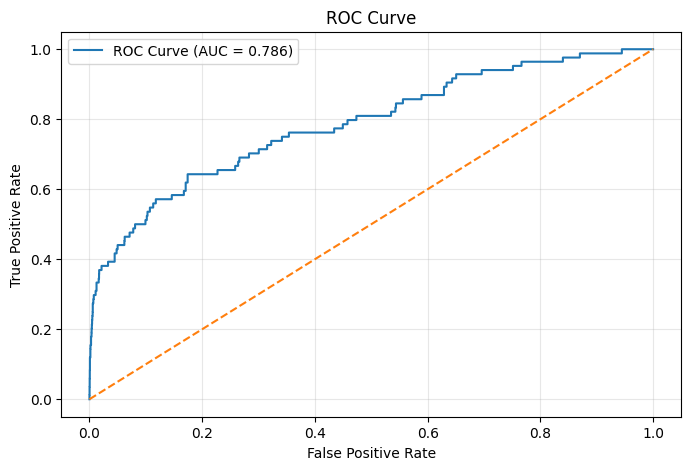

In [34]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_score(y_test, y_prob):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig("figures/roc_curve.png")
plt.show()

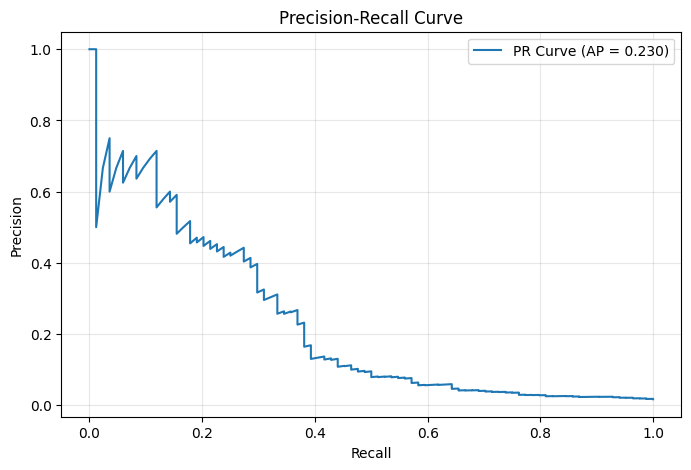

In [35]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, label=f"PR Curve (AP = {avg_precision:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig("figures/pr_curve.png")
plt.show()

## Threshold Tuning Analysis

Threshold tuning was performed to optimise the classification decision boundary of the Random Forest model. By default, classification models use a threshold of 0.5 to convert predicted probabilities into class labels. However, in imbalanced problems such as fraud detection, this default threshold may not provide the best balance between precision and recall.

F1-score was used for threshold optimisation as it provides a balanced measure between precision and recall, which is appropriate for imbalanced classification problems.

Best Threshold (max F1): 0.45


,Threshold,Precision,Recall,F1 Score
22,0.448980,0.378788,0.297619,0.333333
23,0.469388,0.387097,0.285714,0.328767
24,0.489796,0.403509,0.273810,0.326241
21,0.428571,0.342466,0.297619,0.318471
19,0.387755,0.325000,0.309524,0.317073


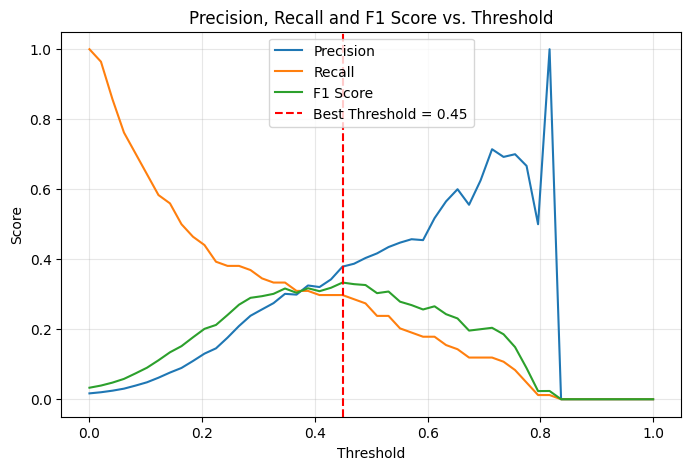

In [36]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Testing multiple probability thresholds
thresholds = np.linspace(0.0, 1.0, 50)

precision_list = []
recall_list = []
f1_list = []

for t in thresholds:
    y_pred_thresh = (y_prob >= t).astype(int)
    
    precision_list.append(precision_score(y_test, y_pred_thresh, zero_division=0))
    recall_list.append(recall_score(y_test, y_pred_thresh))
    f1_list.append(f1_score(y_test, y_pred_thresh))

# Find best threshold maximizing F1 Score
threshold_df = pd.DataFrame({
    "Threshold": thresholds,
    "Precision": precision_list,
    "Recall": recall_list,
    "F1 Score": f1_list
})

best_idx = threshold_df["F1 Score"].idxmax()
best_threshold = threshold_df.loc[best_idx, "Threshold"]

print(f"Best Threshold (max F1): {best_threshold:.2f}")
display(threshold_df.sort_values(by="F1 Score", ascending=False).head())

# Plot the trade-offs
plt.figure(figsize=(8,5))
plt.plot(thresholds, precision_list, label="Precision")
plt.plot(thresholds, recall_list, label="Recall")
plt.plot(thresholds, f1_list, label="F1 Score")
plt.axvline(best_threshold, linestyle="--", color='red', label=f"Best Threshold = {best_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 Score vs. Threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("figures/threshold_tuning_plot.png")
plt.show()

# Save threshold tuning results to tables
threshold_df.to_csv("tables/threshold_tuning_results.csv", index=False)

### Threshold Tuning Impact

Comparing performance before and after threshold tuning:

- **Default Threshold (0.50):**
  - Recall: 0.25
  - Precision: 0.43
  - F1 Score: 0.32

- **Optimized Threshold (0.45):**
  - Recall: 0.30
  - Precision: 0.38
  - F1 Score: 0.33

This shows that lowering the threshold improved the model’s ability to detect fraudulent cases (recall), at the cost of a slight reduction in precision. The increase in F1-score confirms that the new threshold provides a better overall balance between detecting fraud and limiting false alarms.

In real-world fraud detection systems, the threshold may be deliberately set lower than the F1-optimal value to prioritise recall, depending on the business cost of undetected fraud.

The optimal threshold of 0.45 improved recall from 0.25 to 0.30, meaning the model detects more fraudulent cases. Although precision decreased slightly, the overall F1-score improved, indicating a better balance between false positives and false negatives.

This demonstrates that threshold tuning is a critical step in fraud detection, where the cost of missing fraudulent cases is often higher than raising false alarms.

In [37]:
# Re-evaluating with optimized threshold
y_pred_best = (y_prob >= best_threshold).astype(int)

print(f"Performance with Optimized Threshold ({best_threshold:.2f}):\n")
print(classification_report(y_test, y_pred_best))
# Save detailed reports
with open("reports/model_summary.txt", "w") as f:
    f.write(results_df.to_string())
if "threshold_df" in locals():
    with open("reports/threshold_summary.txt", "w") as f:
        f.write(threshold_df.to_string())
logging.info("Detailed reports saved to reports/")

Performance with Optimized Threshold (0.45):

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4943
           1       0.38      0.30      0.33        84

    accuracy                           0.98      5027
   macro avg       0.68      0.64      0.66      5027
weighted avg       0.98      0.98      0.98      5027



### Final Evaluation Insight

The ROC curve indicates that the model performs significantly better than random guessing, as shown by the high AUC score.

While ROC-AUC indicates overall separability, the Precision-Recall curve is more informative for this imbalanced dataset, as it focuses on the minority class performance.

The Precision-Recall curve provides a more realistic view of performance under class imbalance. The model maintains a reasonable balance between precision and recall, which is crucial in fraud detection tasks.

Potential improvements include the use of resampling techniques such as SMOTE to balance the minority class, as well as threshold tuning to optimise the trade-off between precision and recall. While class_weight was used to mitigate imbalance, additional techniques such as SMOTE or ensemble resampling methods could further improve recall performance. Additionally, cost-sensitive learning approaches could be explored to further prioritise fraud detection. These steps would address the current recall limitations and enhance the model's operational viability.

In real-world deployment, threshold selection may be adjusted further based on business risk tolerance, where higher recall may be prioritised over precision to minimise undetected fraud.

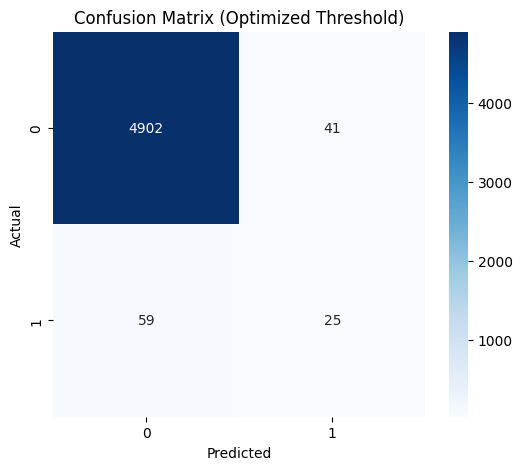

In [38]:
import seaborn as sns

# Generate confusion matrix using the optimized threshold predictions
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Optimized Threshold)")

plt.savefig("figures/confusion_matrix.png")
plt.show()

The confusion matrix shows that the model correctly classifies the majority of non-fraud cases (true negatives), while detecting a smaller portion of fraudulent cases (true positives). However, a noticeable number of fraud cases are misclassified as non-fraud (false negatives), which is a critical issue in fraud detection since undetected fraud leads to financial loss. This reinforces the importance of improving recall in future work.